<a href="https://colab.research.google.com/github/akuntugasrapon/image-processing/blob/main/image_enhancement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [4]:
img = Image.open("image.jpg").convert("L")
img = np.array(img)

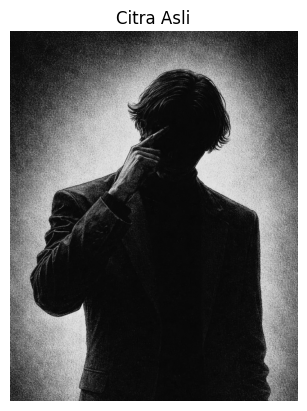

In [5]:
plt.imshow(img, cmap='gray')
plt.title("Citra Asli")
plt.axis("off")
plt.show()

In [6]:
hist = np.zeros(256)

for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        pixel = img[i, j]
        hist[pixel] += 1

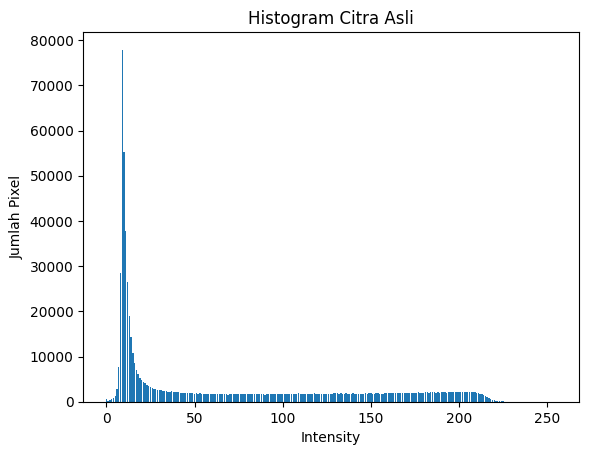

In [7]:
plt.figure()
plt.bar(range(256), hist)
plt.title("Histogram Citra Asli")
plt.xlabel("Intensity")
plt.ylabel("Jumlah Pixel")
plt.show()

In [8]:
total_pixel = img.shape[0] * img.shape[1]

In [9]:
hist_norm = hist / total_pixel

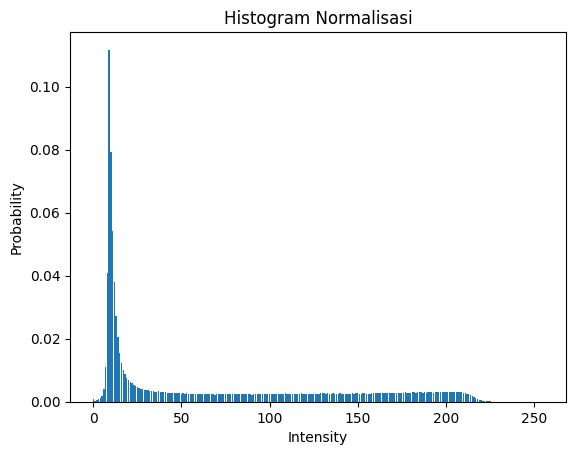

In [10]:
plt.figure()
plt.bar(range(256), hist_norm)
plt.title("Histogram Normalisasi")
plt.xlabel("Intensity")
plt.ylabel("Probability")
plt.show()

In [11]:
cdf = np.cumsum(hist_norm)

In [12]:
equalized = np.zeros_like(img)

for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        equalized[i, j] = int(255 * cdf[img[i, j]])

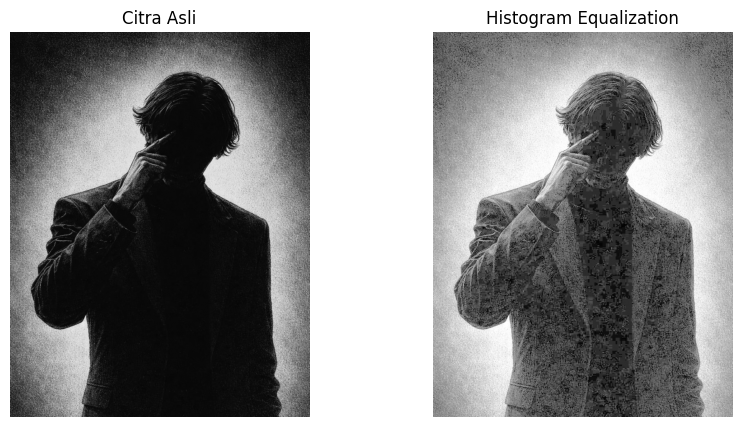

In [13]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Citra Asli")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(equalized, cmap='gray')
plt.title("Histogram Equalization")
plt.axis("off")

plt.show()

In [14]:
hist_eq = np.zeros(256)

for i in range(equalized.shape[0]):
    for j in range(equalized.shape[1]):
        hist_eq[equalized[i,j]] += 1

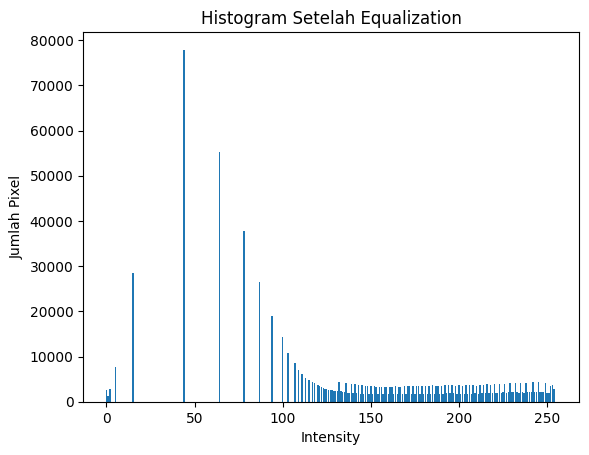

In [15]:
plt.figure()
plt.bar(range(256), hist_eq)
plt.title("Histogram Setelah Equalization")
plt.xlabel("Intensity")
plt.ylabel("Jumlah Pixel")
plt.show()

In [16]:
Image.fromarray(equalized).save("hasil_equalization.jpg")